# Financial Analysis of 5 Big Tech

Is the AI infrastructure boom putting pressure on Big Tech's free cash flow?

 **Yes, but unevenly.**

Microsoft's CapEx rose from 8% to 35% of revenue (2017–2026) while its FCF margin fell from 33% to 20%. Meta shows a similar pattern.
Apple is the exception — its CapEx barely moved, and its FCF margin stayed stable (~25%).
The pressure is concentrated in companies actually building AI infrastructure, not spread
evenly across the industry. Full evidence is in the Key Findings section below.

This notebook explores annual financial data (10-K filings from the SEC Company Facts API) for five companies: Microsoft (MSFT), Apple (AAPL), Alphabet (GOOGL), Meta (META) and Amazon (AMZN).
The goal is to identify key trends, patterns and differences in the performance of the companies over time: growth, profitability, returns, debt, investment and free cash flow.

## Data Loading and Cleaning

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("companies_annual.csv")
df.head()

,Ticker,Year,PeriodEnd,Revenue,NetProfit,Assets,Liabilities,Equity,Cash,ShortTermInvestments,Debt,OperatingCashFlow,CapEx,SourceFiled
0,MSFT,2017,2017-06-30,96571000000,25489000000,250312000000,162601000000,87711000000,7663000000,NaN,8.619400e+10,39507000000,8.129000e+09,2018-08-03
1,MSFT,2018,2018-06-30,110360000000,16571000000,258848000000,176130000000,82718000000,11946000000,1.218220e+11,7.624000e+10,43884000000,1.163200e+10,2019-08-01
2,MSFT,2019,2019-06-30,125843000000,39240000000,286556000000,184226000000,102330000000,11356000000,1.224630e+11,7.217800e+10,52185000000,1.392500e+10,2020-07-30
3,MSFT,2020,2020-06-30,143015000000,44281000000,301311000000,183007000000,118304000000,13576000000,1.229510e+11,6.332700e+10,60675000000,1.544100e+10,2021-07-29
4,MSFT,2021,2021-06-30,168088000000,61271000000,333779000000,191791000000,141988000000,14224000000,1.161100e+11,5.814600e+10,76740000000,2.062200e+10,2022-07-28


In [3]:
df.isna().sum()

,0
Ticker,0
Year,0
PeriodEnd,0
Revenue,0
NetProfit,0
Assets,0
Liabilities,0
Equity,0
Cash,0
ShortTermInvestments,6


In [4]:
# check duplicates
df.duplicated(subset=["Ticker", "Year"]).sum()

np.int64(0)

In [5]:
df["PeriodEnd"] = pd.to_datetime(df["PeriodEnd"])
df["SourceFiled"] = pd.to_datetime(df["SourceFiled"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Ticker                46 non-null     object        
 1   Year                  46 non-null     int64         
 2   PeriodEnd             46 non-null     datetime64[ns]
 3   Revenue               46 non-null     int64         
 4   NetProfit             46 non-null     int64         
 5   Assets                46 non-null     int64         
 6   Liabilities           46 non-null     int64         
 7   Equity                46 non-null     int64         
 8   Cash                  46 non-null     int64         
 9   ShortTermInvestments  40 non-null     float64       
 10  Debt                  46 non-null     float64       
 11  OperatingCashFlow     46 non-null     int64         
 12  CapEx                 46 non-null     float64       
 13  SourceFiled           

In [6]:
df[df["ShortTermInvestments"].isna()][["Ticker", "Year"]]

,Ticker,Year
0,MSFT,2017
10,AAPL,2017
28,META,2017
29,META,2018
30,META,2019
31,META,2020


ShortTermInvestments is missing for MSFT and AAPL in 2017 and for META from 2017 to 2020, because these companies did not report it under the tag used. The column is not used in any of the metrics below, so it does not affect the results.

In [7]:

palette = dict(zip(sorted(df["Ticker"].unique()), sns.color_palette("Set1")))

## Financial Metrics

In [8]:
df["Net Margin"] = df["NetProfit"] / df["Revenue"] * 100
df["ROE"] = df["NetProfit"] / df["Equity"] * 100
df["ROA"] = df["NetProfit"] / df["Assets"] * 100
df["Debt To Equity"] = df["Debt"] / df["Equity"]
df["Free Cash Flow"] = df["OperatingCashFlow"] - df["CapEx"]
df["CapEx Intensity"] = df["CapEx"] / df["Revenue"] * 100
df["FCF Margin"] = df["Free Cash Flow"] / df["Revenue"] * 100

# values in billions, used in the charts
df["Revenue_B"] = df["Revenue"] / 1e9
df["NetProfit_B"] = df["NetProfit"] / 1e9
df["CapEx_B"] = df["CapEx"] / 1e9

metrics = ["Net Margin", "ROE", "ROA", "Debt To Equity", "CapEx Intensity", "FCF Margin"]

In [9]:
df[["Ticker", "Year"] + metrics + ["Free Cash Flow"]].round(3)

,Ticker,Year,Net Margin,ROE,ROA,Debt To Equity,CapEx Intensity,FCF Margin,Free Cash Flow
0,MSFT,2017,26.394,29.060,10.183,0.983,8.418,32.492,3.137800e+10
1,MSFT,2018,15.015,20.033,6.402,0.922,10.540,29.224,3.225200e+10
2,MSFT,2019,31.182,38.347,13.694,0.705,11.065,30.403,3.826000e+10
3,MSFT,2020,30.962,37.430,14.696,0.535,10.797,31.629,4.523400e+10
4,MSFT,2021,36.452,43.152,18.357,0.410,12.269,33.386,5.611800e+10
5,MSFT,2022,36.686,43.675,19.937,0.299,12.047,32.859,6.514900e+10
6,MSFT,2023,34.146,35.089,17.564,0.229,13.263,28.065,5.947500e+10
7,MSFT,2024,35.956,32.828,17.209,0.192,18.145,30.218,7.407100e+10
8,MSFT,2025,36.146,29.647,16.451,0.126,22.913,25.419,7.161100e+10
9,MSFT,2026,40.305,30.233,17.636,0.091,34.941,20.187,6.698700e+10


## Company Comparison

In [10]:
df[metrics].describe().round(3)

,Net Margin,ROE,ROA,Debt To Equity,CapEx Intensity,FCF Margin
count,46.000,46.000,46.000,46.000,46.000,46.000
mean,23.617,43.075,15.618,0.512,13.195,21.905
std,11.247,45.327,7.191,0.620,7.992,10.644
min,-0.530,-1.864,-0.588,0.000,2.416,-3.287
25%,20.150,20.204,10.749,0.063,7.145,18.425
50%,25.308,28.445,16.435,0.250,12.127,23.938
75%,32.403,37.090,19.666,0.824,18.004,28.984
max,40.305,196.959,31.180,2.370,34.941,43.005


In [11]:
# mean of each company
Company_avg = df.groupby("Ticker")[metrics].mean().round(3)
Company_avg

,Net Margin,ROE,ROA,Debt To Equity,CapEx Intensity,FCF Margin
Ticker,,,,,,
AAPL,23.671,117.797,22.539,1.577,3.469,25.256
AMZN,5.297,16.949,5.819,0.418,10.538,3.431
GOOGL,23.700,22.561,16.114,0.052,13.991,21.075
META,32.122,25.134,18.452,0.070,22.289,29.543
MSFT,32.325,33.949,15.213,0.449,15.440,29.388


Microsoft has 10 years of data (FY2017 to FY2026) while the other companies have 9 (2017 to 2025), so the averages do not cover exactly the same period.

## Visualizations

**How has revenue evolved over time for each company?**

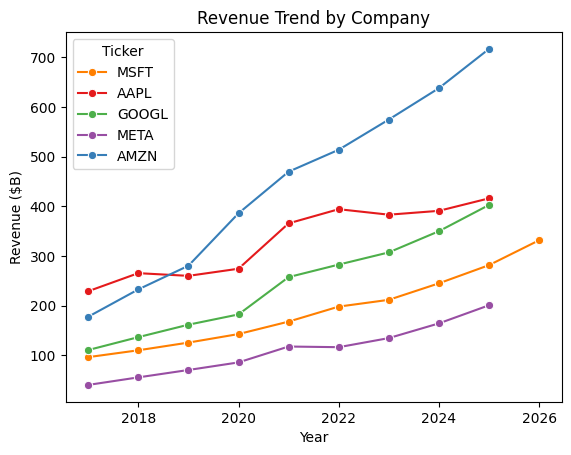

In [12]:
sns.lineplot(data=df, x="Year", y="Revenue_B", hue="Ticker", palette=palette, marker="o")
plt.title("Revenue Trend by Company")
plt.ylabel("Revenue ($B)")
plt.show()

**How has net profit changed over time for each company?**

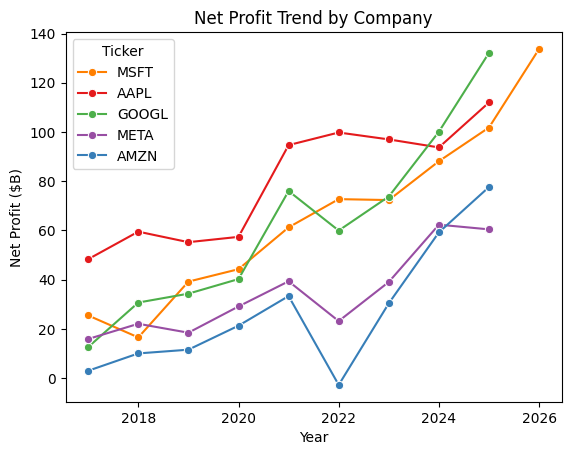

In [13]:
sns.lineplot(data=df, x="Year", y="NetProfit_B", hue="Ticker", palette=palette, marker="o")
plt.title("Net Profit Trend by Company")
plt.ylabel("Net Profit ($B)")
plt.show()

**Is higher revenue associated with higher net profit across companies and years?**

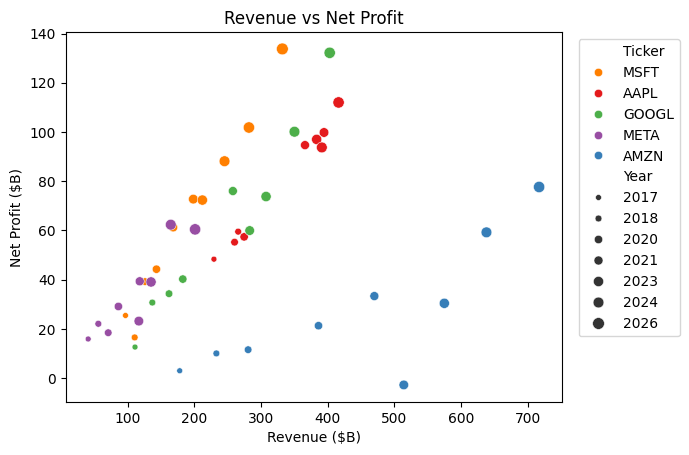

In [14]:
sns.scatterplot(data=df, x="Revenue_B", y="NetProfit_B", hue="Ticker", palette=palette, size="Year")

plt.title("Revenue vs Net Profit")
plt.xlabel("Revenue ($B)")
plt.ylabel("Net Profit ($B)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

### Profitability and Returns

**How does average net margin differ between companies?**

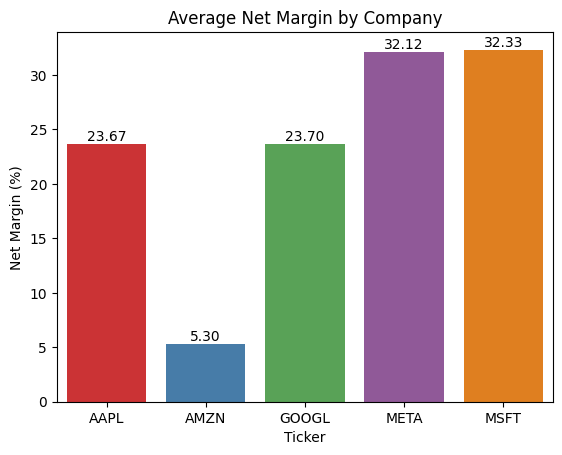

In [15]:
ax = sns.barplot(data=Company_avg.reset_index(), x="Ticker", y="Net Margin",
                 hue="Ticker", palette=palette, legend=False)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f")
plt.title("Average Net Margin by Company")
plt.ylabel("Net Margin (%)")
plt.show()

**How has return on equity changed over time for each company?**

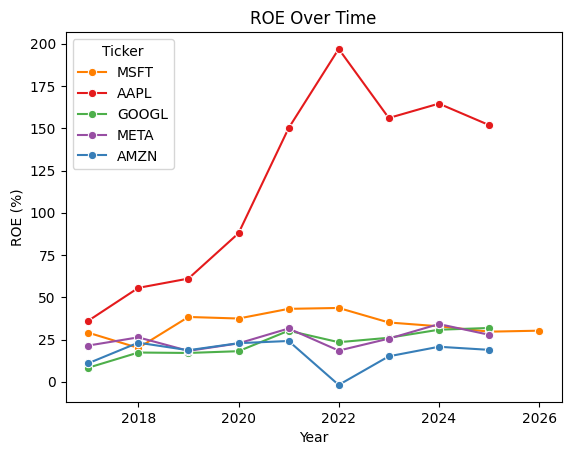

In [16]:
sns.lineplot(data=df, x="Year", y="ROE", hue="Ticker", palette=palette, marker="o")
plt.title("ROE Over Time")
plt.ylabel("ROE (%)")
plt.show()

**How has return on assets changed over time for each company?**

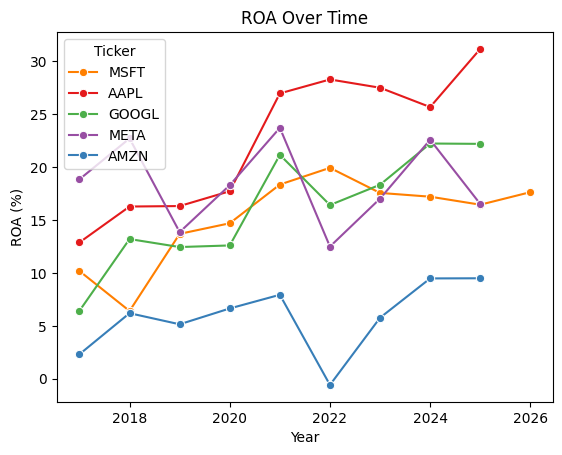

In [17]:
sns.lineplot(data=df, x="Year", y="ROA", hue="Ticker", palette=palette, marker="o")
plt.title("ROA Over Time")
plt.ylabel("ROA (%)")
plt.show()

### Debt and Balance Sheet

**How has the debt-to-equity ratio changed over time for each company?**

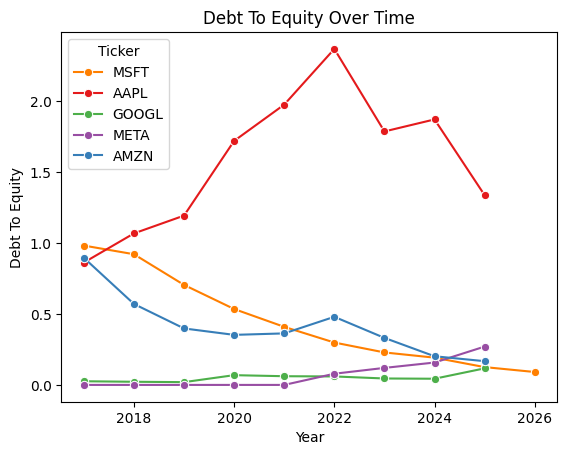

In [18]:
sns.lineplot(data=df, x="Year", y="Debt To Equity", hue="Ticker", palette=palette, marker="o")
plt.title("Debt To Equity Over Time")
plt.show()

**How is each company’s asset base financed through liabilities and equity?**

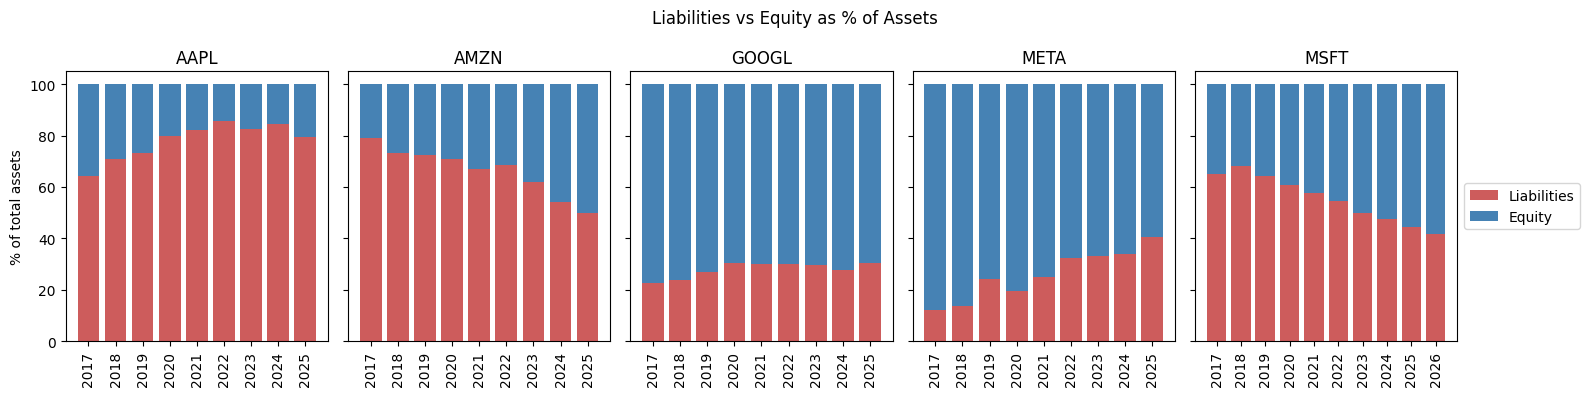

In [19]:
fig, axes = plt.subplots(1, df["Ticker"].nunique(), figsize=(16, 4), sharey=True)

for ax, (t, d) in zip(axes, df.groupby("Ticker")):
    liab = d["Liabilities"] / d["Assets"] * 100
    ax.bar(d["Year"], liab, color="indianred", label="Liabilities")
    ax.bar(d["Year"], d["Equity"] / d["Assets"] * 100, bottom=liab, color="steelblue", label="Equity")
    ax.set_title(t)
    ax.set_xticks(d["Year"])
    ax.tick_params(axis="x", rotation=90)

axes[0].set_ylabel("% of total assets")
axes[-1].legend(bbox_to_anchor=(1, 0.5), loc="center left")
plt.suptitle("Liabilities vs Equity as % of Assets")
plt.tight_layout()
plt.show()

### Investment and Cash Flow

**How has capital expenditure changed over time for each company?**

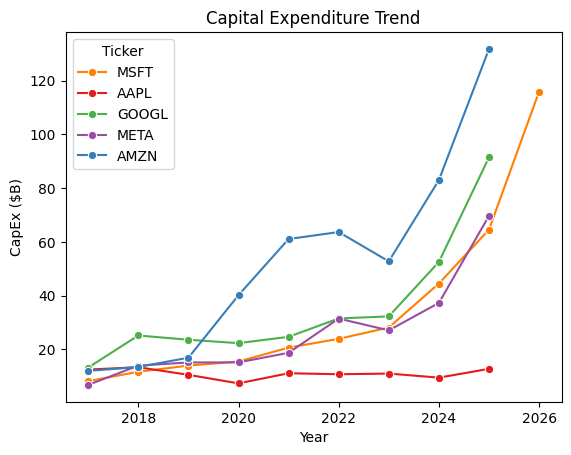

In [20]:
sns.lineplot(data=df, x="Year", y="CapEx_B", hue="Ticker", palette=palette, marker="o")
plt.title("Capital Expenditure Trend")
plt.ylabel("CapEx ($B)")
plt.show()

**How has capital expenditure intensity changed over time for each company?**

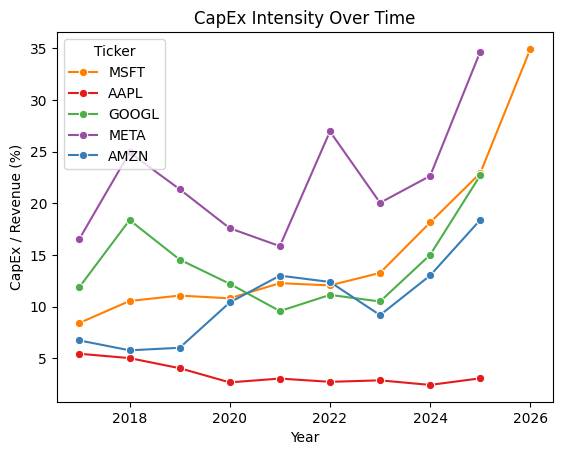

In [21]:
sns.lineplot(data=df, x="Year", y="CapEx Intensity", hue="Ticker", palette=palette, marker="o")
plt.title("CapEx Intensity Over Time")
plt.ylabel("CapEx / Revenue (%)")
plt.show()

**How has free cash flow margin changed over time for each company?**

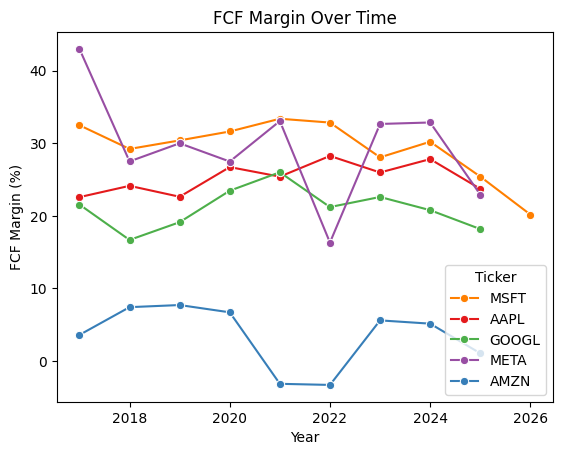

In [22]:
sns.lineplot(data=df, x="Year", y="FCF Margin", hue="Ticker", palette=palette, marker="o")
plt.title("FCF Margin Over Time")
plt.ylabel("FCF Margin (%)")
plt.show()

**How does average free cash flow margin differ between companies?**

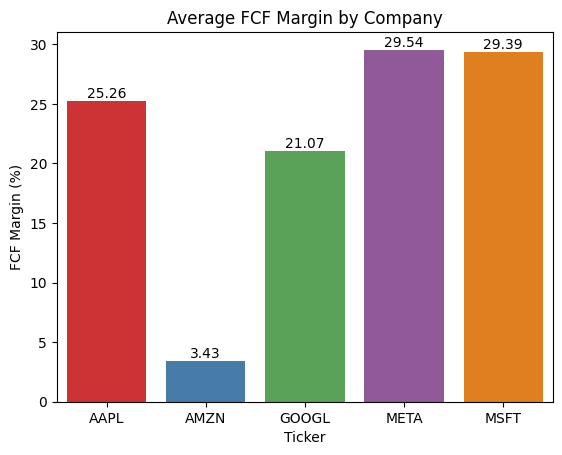

In [23]:
ax = sns.barplot(data=Company_avg.reset_index(), x="Ticker", y="FCF Margin",
                 hue="Ticker", palette=palette, legend=False)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f")
plt.title("Average FCF Margin by Company")
plt.ylabel("FCF Margin (%)")
plt.show()

### Relationships Between Metrics

**How are the key financial metrics related to each other?**

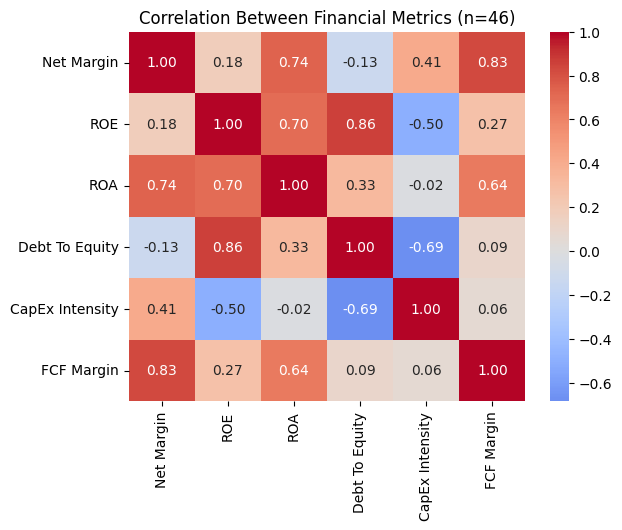

In [24]:
corr = df[metrics].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(f"Correlation Between Financial Metrics (n={len(df)})")
plt.show()

The heatmap mixes all companies and years together, so some of the correlations are mostly driven by Apple, which has a very high ROE and debt ratio. They are better read as general hints than as strong evidence.

**Correlation by company**

To avoid mixing the companies, the cell below calculates the correlation between `CapEx Intensity` and `FCF Margin` separately for each company.

In [25]:
corr_by_company = pd.Series({t: g["CapEx Intensity"].corr(g["FCF Margin"]) for t, g in df.groupby("Ticker")})
corr_by_company.rename("CapEx Intensity vs FCF Margin").round(3)

,CapEx Intensity vs FCF Margin
AAPL,-0.779
AMZN,-0.602
GOOGL,-0.819
META,-0.692
MSFT,-0.903


All five companies have a negative correlation, from -0.60 for Amazon to -0.90 for Microsoft. Apple is also strongly negative (-0.78) even though its CapEx is small. Part of this is expected because CapEx is subtracted when FCF is calculated, and each company only has 9 or 10 years of data, so the numbers should not be over-interpreted.

## Key Findings

1. **Microsoft and Meta increased their CapEx significantly.**
   CapEx increased as a percentage of revenue, especially for Microsoft and Meta.

2. **Higher CapEx was associated with lower FCF margins.**
   Microsoft and Meta saw their FCF margins decrease as CapEx increased. This relationship is partly mechanical because CapEx is subtracted when calculating FCF.

3. **Apple's FCF margin remained relatively stable.**
   Apple's CapEx intensity changed only slightly, while its FCF margin stayed around 25%.

4. **Apple's ROE was unusually high.**
   Apple's ROE reached nearly 197%, so it should be interpreted carefully. Its relatively small equity base makes ROE less comparable with the other companies.

5. **Amazon had negative FCF in 2021 and 2022.**
   This happened during a period of high investment. Amazon also reported a significant loss in 2022, partly related to its investment in Rivian.

6. **Debt levels varied across companies.**
   Apple had relatively high Debt-to-Equity, while Google and Meta had lower levels for most of the period.

7. **Fiscal year-ends are different across companies.**
   Microsoft ends its fiscal year in June, Apple in September, and Google, Meta, and Amazon in December. Therefore, the same "Year" does not represent exactly the same period for every company.
